In [2]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import nilearn.plotting as nlp
import pyvista as pv
import pandas as pd
import yabplot as yab
import dicom2nifti
from pathlib import Path


In [3]:
dicom_dir = Path("_data/ADNI/002_S_5178/Accelerated_Sagittal_MPRAGE__MSV21_/2025-12-03_09_14_01.0/I11503312")
output_dir = Path("processed_data")
output_dir.mkdir(exist_ok=True)

dicom2nifti.convert_directory(str(dicom_dir), str(output_dir), compression=True, reorient=True)

nifti_path = next(output_dir.glob("*.nii.gz"))
print(f"Created: {nifti_path}")

c:\Users\user\Desktop\MRI_eval\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.89.05738945364910309432'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


Created: processed_data\2_accelerated_sagittal_mprage_msv21.nii.gz


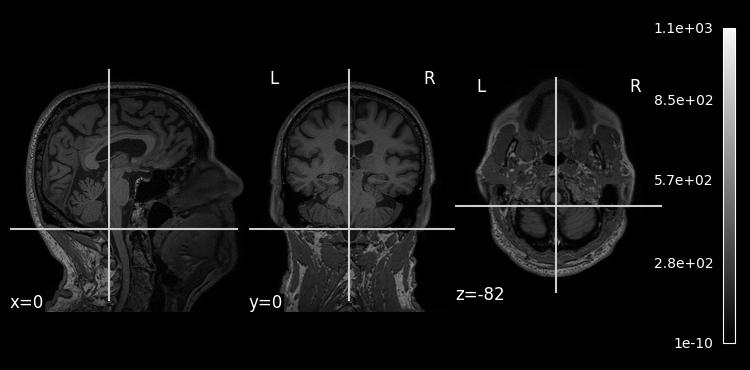

In [4]:
nlp.plot_anat(str(nifti_path), display_mode='ortho')
plt.show()

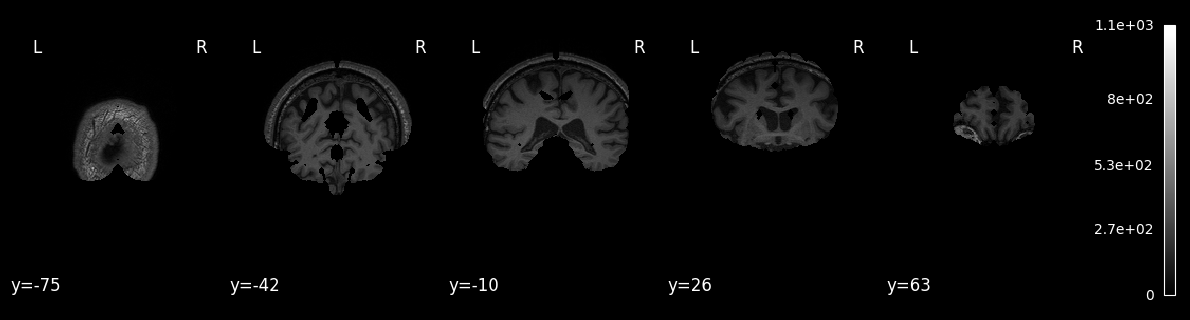

In [9]:
brain_only_path = "processed_data/brain_only.nii.gz"
nlp.plot_anat(str(brain_only_path), display_mode='y', cut_coords=5)
plt.show()

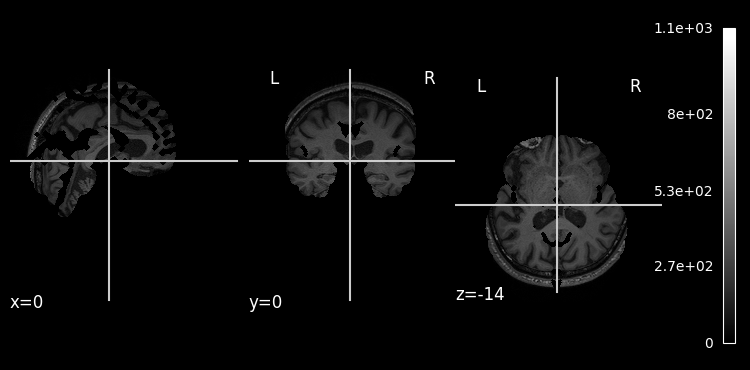

In [11]:
brain_only_path = "processed_data/brain_only.nii.gz"
nlp.plot_anat(str(brain_only_path), cut_coords=[0, 0, -14])
plt.show()

Calculated COG (voxels): (np.float64(104.83880513957679), np.float64(109.72292087923776), np.float64(110.38154614516246))


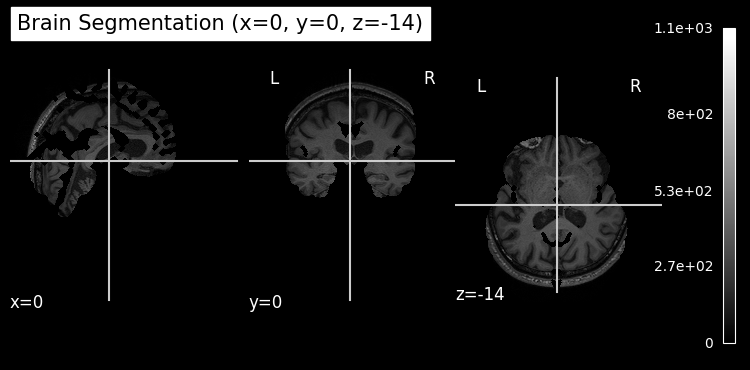

In [13]:
from scipy import ndimage
from nilearn import masking

img = nib.load(str(nifti_path))
data = img.get_fdata()


cog = ndimage.center_of_mass(data)
print(f"Calculated COG (voxels): {cog}")

brain_mask = masking.compute_brain_mask(img)
brain_data = data * brain_mask.get_fdata()
brain_img = nib.Nifti1Image(brain_data, img.affine, img.header)

brain_only_path = "processed_data/brain_only.nii.gz"
brain_img.to_filename(brain_only_path)

nlp.plot_anat(str(brain_only_path), 
              display_mode='ortho', 
              cut_coords=[0, 0, -14],
              title="Brain Segmentation (x=0, y=0, z=-14)")
plt.show()

Calculated COG (voxels): (np.float64(104.90912781723995), np.float64(108.63145590755528), np.float64(109.79001412052179))
Calculated COG (world): [  0.59586944   9.5724578  -55.91037956]


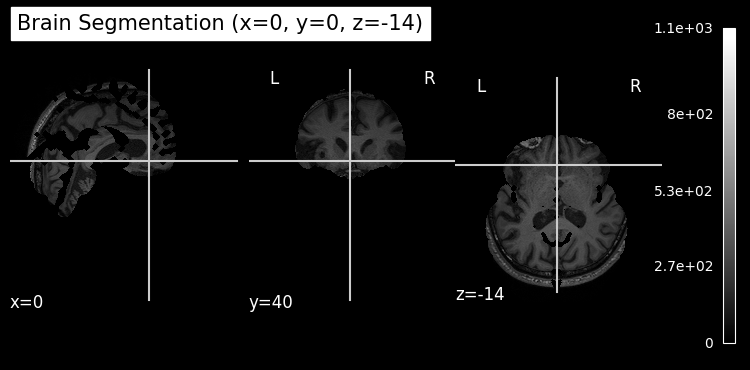

In [ ]:
img = nib.load(str(nifti_path))
data = img.get_fdata()

threshold = np.mean(data)
mask_for_cog = data > threshold
cog_voxels = ndimage.center_of_mass(data * mask_for_cog)


cog_world = nib.affines.apply_affine(img.affine, cog_voxels)
print(f"Calculated COG (voxels): {cog_voxels}")
print(f"Calculated COG (world): {cog_world}")

brain_mask = masking.compute_brain_mask(img)
brain_data = data * brain_mask.get_fdata()
brain_img = nib.Nifti1Image(brain_data, img.affine, img.header)

brain_only_path = "processed_data/brain_only.nii.gz"
brain_img.to_filename(brain_only_path)

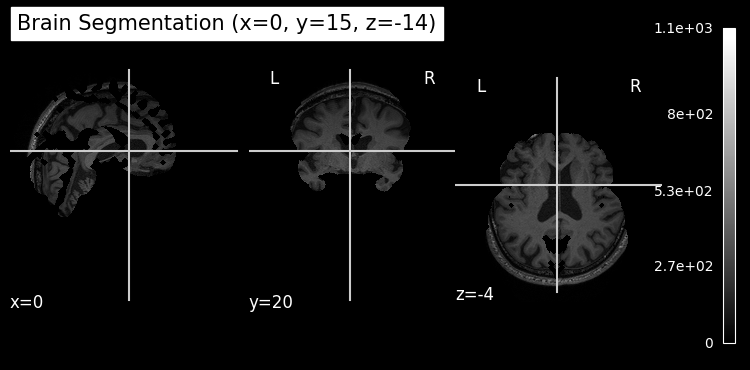

In [ ]:
nlp.plot_anat(str(brain_only_path),
              display_mode='ortho',
              cut_coords=[0, 20, -4
              ],
              title="Brain Segmentation (0, 20, -4)")
plt.show()

Unzipping contents of 'C:\Users\user\AppData\Local\yabplot\yabplot\Cache\bmesh-midthickness.zip' to 'C:\Users\user\AppData\Local\yabplot\yabplot\Cache\bmesh-midthickness'
Unzipping contents of 'C:\Users\user\AppData\Local\yabplot\yabplot\Cache\subcortical-aseg.zip' to 'C:\Users\user\AppData\Local\yabplot\yabplot\Cache\subcortical-aseg'


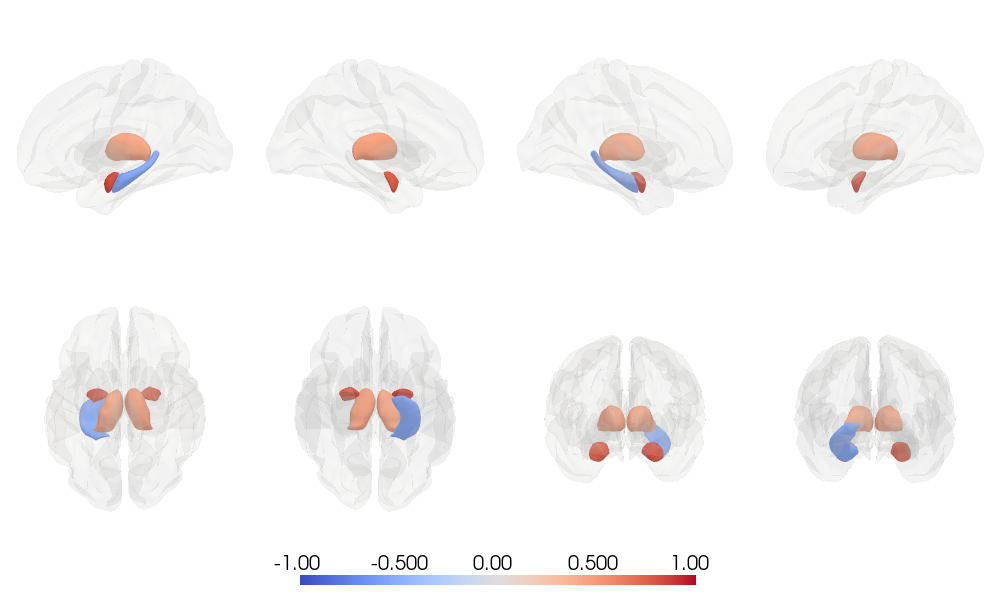

In [7]:
roi_data = {
    'Left_Amygdala': 0.8,
    'Right_Amygdala': 0.75,
    'Left_Thalamus': 0.4,
    'Right_Thalamus': 0.45,
    'Left_Hippocampus': -0.5
}

yab.plot_subcortical(
    data=roi_data,
    atlas='aseg',
    cmap='coolwarm',
    vminmax=[-1, 1],   
    nan_alpha=0.1,     
    display_type='static'
)

Unzipping contents of 'C:\Users\user\AppData\Local\yabplot\yabplot\Cache\cortical-schaefer_100.zip' to 'C:\Users\user\AppData\Local\yabplot\yabplot\Cache\cortical-schaefer_100'


atlas 'schaefer_100' has 100 regions.
first 3: ['7Networks_LH_Vis_1', '7Networks_LH_Vis_2', '7Networks_LH_Vis_3']


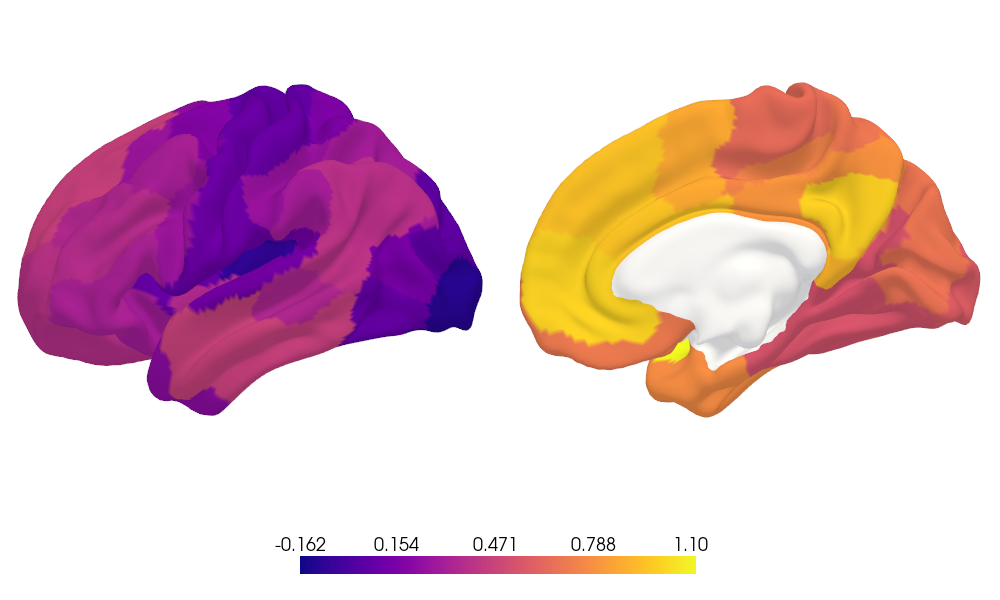

In [8]:
atlas_name = 'schaefer_100'
regions = yab.get_atlas_regions(atlas_name, 'cortical')

print(f"atlas '{atlas_name}' has {len(regions)} regions.")
print(f"first 3: {regions[:3]}")

data_array = np.linspace(0, 1, len(regions)) 
data_array += np.random.normal(0, 0.1, len(regions))

yab.plot_cortical(
    data=data_array,
    atlas=atlas_name,
    cmap='plasma',
    views=['left_lateral', 'right_medial'],
    display_type='static'
)

       fa_value
AC     0.356917
AF_L   0.755955
AF_R   0.652375
AR_R   0.392166
ATR_L  0.284961


Unzipping contents of 'C:\Users\user\AppData\Local\yabplot\yabplot\Cache\bmesh-inflated.zip' to 'C:\Users\user\AppData\Local\yabplot\yabplot\Cache\bmesh-inflated'


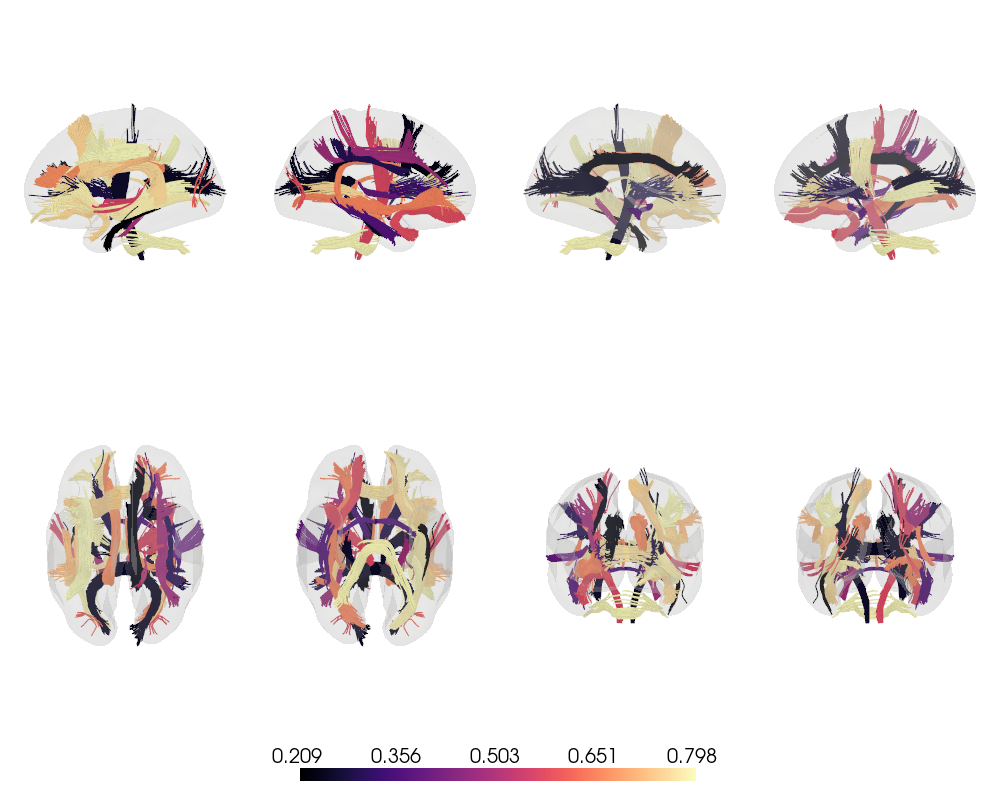

In [10]:
tract_names = yab.get_atlas_regions('xtract_tiny', 'tracts')

df = pd.DataFrame({
    'fa_value': np.random.uniform(0.2, 0.8, len(tract_names))
}, index=tract_names)

print(df.head())

yab.plot_tracts(
    data=df['fa_value'],
    atlas='xtract_tiny',
    cmap='magma',
    style='matte',
    bmesh_type='inflated',
    display_type='static'
)

In [12]:
import SimpleITK as sitk
from nilearn import masking, image
import numpy as np


'''skull strip'''
mask_img = masking.compute_brain_mask(str(nifti_path))
brain_img = image.math_img("img * mask", img=str(nifti_path), mask=mask_img)
brain_img.to_filename("processed_data/brain_only.nii.gz")

'''N4 Bias Field Correction'''
sitk_img = sitk.ReadImage("processed_data/brain_only.nii.gz", sitk.sitkFloat32)

mask_array = mask_img.get_fdata().astype(np.uint8).transpose()
mask_sitk = sitk.GetImageFromArray(mask_array)
mask_sitk.CopyInformation(sitk_img)

corrector = sitk.N4BiasFieldCorrectionImageFilter()
corrected_sitk = corrector.Execute(sitk_img, mask_sitk)
sitk.WriteImage(corrected_sitk, "processed_data/corrected.nii.gz")

'''Intensity Normalization (Z-score)'''
brain_data = sitk.GetArrayFromImage(corrected_sitk)
brain_voxels = brain_data[brain_data > 0]
norm_data = (brain_data - np.mean(brain_voxels)) / np.std(brain_voxels)

norm_sitk = sitk.GetImageFromArray(norm_data)
norm_sitk.CopyInformation(corrected_sitk)
sitk.WriteImage(norm_sitk, "processed_data/normalized.nii.gz")


N4 Bias Correction (this may take a minute)...


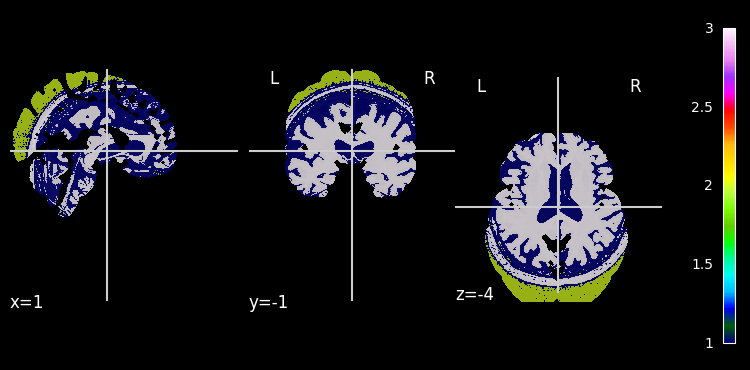

In [14]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

brain_voxels_flat = norm_data[brain_data > 0].reshape(-1, 1)

gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(brain_voxels_flat)
labels = gmm.predict(brain_voxels_flat)

seg_data = np.zeros_like(norm_data)
seg_data[brain_data > 0] = labels + 1

seg_img = sitk.GetImageFromArray(seg_data)
seg_img.CopyInformation(norm_sitk)
sitk.WriteImage(seg_img, "processed_data/segmentation.nii.gz")

nlp.plot_roi("processed_data/segmentation.nii.gz", 
             bg_img="processed_data/normalized.nii.gz")
plt.show()

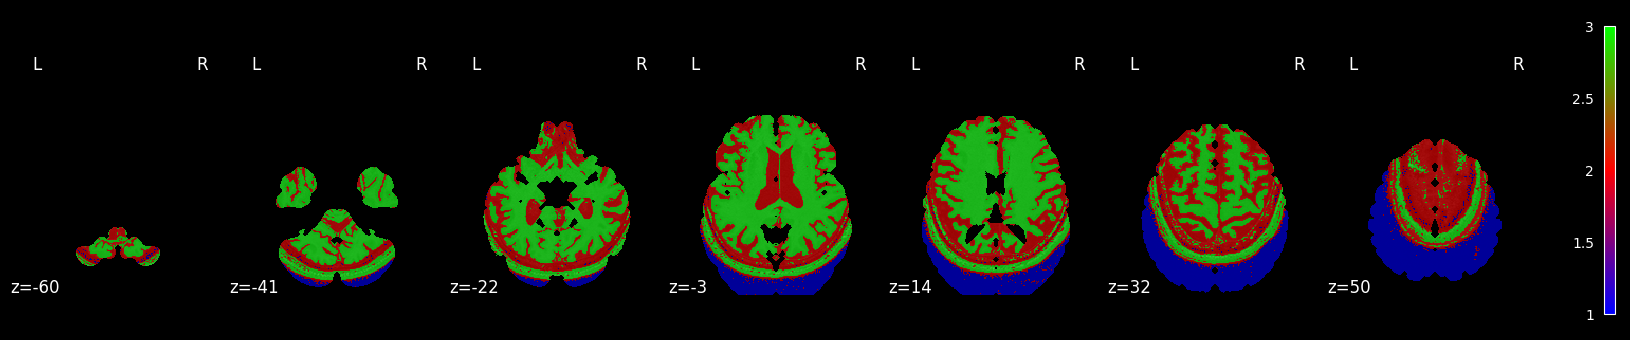

In [15]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

brain_voxels_flat = norm_data[brain_data > 0].reshape(-1, 1)
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(brain_voxels_flat)

idx = np.argsort(gmm.means_.flatten())
labels = gmm.predict(brain_voxels_flat)

new_labels = np.zeros_like(labels)
for i, cluster_idx in enumerate(idx):
    new_labels[labels == cluster_idx] = i


seg_data = np.zeros_like(norm_data)
seg_data[brain_data > 0] = new_labels + 1

seg_img = sitk.GetImageFromArray(seg_data)
seg_img.CopyInformation(norm_sitk)
sitk.WriteImage(seg_img, "processed_data/segmentation.nii.gz")

nlp.plot_roi(
    "processed_data/segmentation.nii.gz",
    bg_img="processed_data/normalized.nii.gz",
    display_mode='z',
    cut_coords=7,
    alpha=0.6,
    cmap='brg'
)
plt.show()

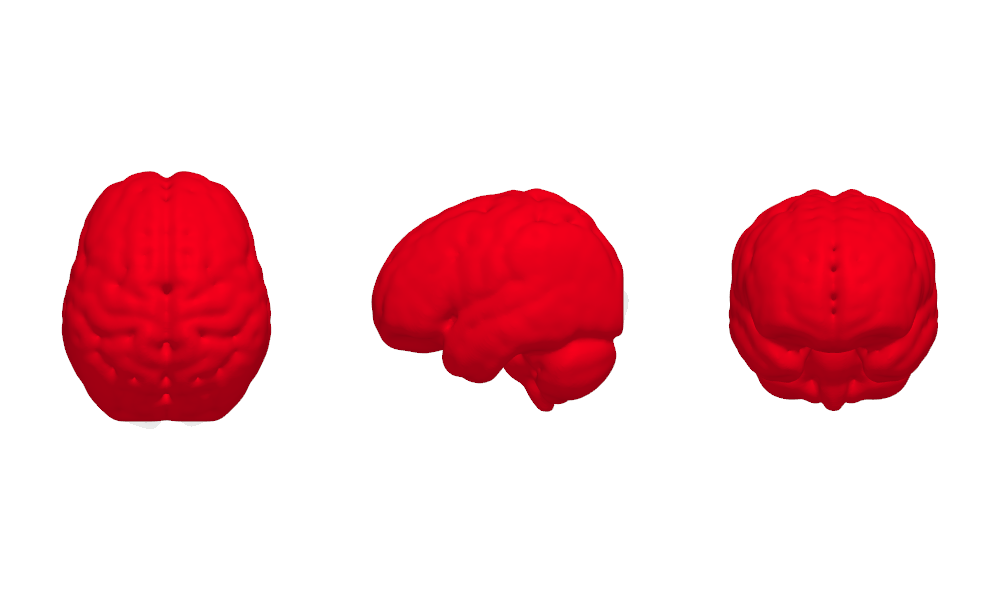

In [19]:
import numpy as np
import nibabel as nib
from skimage import measure
import yabplot as yab
from pathlib import Path

brain_path = "processed_data/brain_only.nii.gz"
output_dir = Path("processed_data/structural_surface")
output_dir.mkdir(parents=True, exist_ok=True)

img = nib.load(brain_path)
data = img.get_fdata()
affine = img.affine

mask = (data > 0).astype(np.uint8)

verts, faces, _, _ = measure.marching_cubes(mask, level=0.5)
verts_transformed = nib.affines.apply_affine(affine, verts)

coord_array = nib.gifti.GiftiDataArray(data=verts_transformed.astype(np.float32), intent='NIFTI_INTENT_POINTSET')
face_array = nib.gifti.GiftiDataArray(data=faces.astype(np.int32), intent='NIFTI_INTENT_TRIANGLE')
gii = nib.gifti.GiftiImage(darrays=[coord_array, face_array])
nib.save(gii, str(output_dir / "PatientBrain.surf.gii"))

yab.plot_subcortical(
    custom_atlas_path=str(output_dir),
    views=['superior', 'left_lateral', 'anterior'],
    style='sculpted',
    custom_atlas_proc={'smooth_i': 40, 'smooth_f': 0.6}, 
    display_type='static'
)

  - Saved surface: Tissue_Class_1
  - Saved surface: Tissue_Class_2
  - Saved surface: Tissue_Class_3


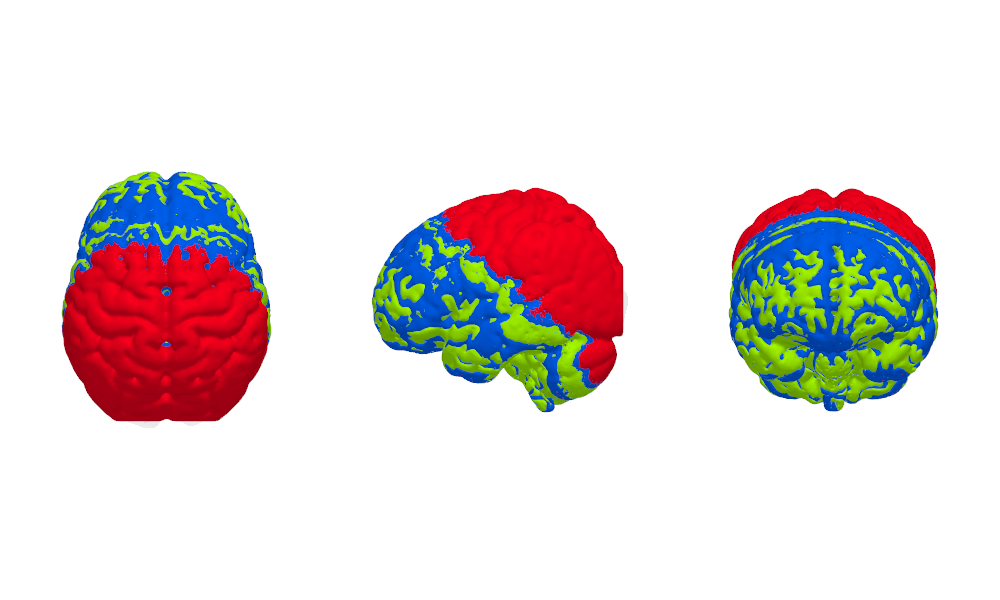

In [17]:
import os
import numpy as np
import nibabel as nib
from skimage import measure
import yabplot as yab
from pathlib import Path

seg_path = "processed_data/segmentation.nii.gz"
output_dir = Path("processed_data/patient_surfaces")
output_dir.mkdir(parents=True, exist_ok=True)

roi_names = {
    1: "Tissue_Class_1",
    2: "Tissue_Class_2",
    3: "Tissue_Class_3"
}

img = nib.load(seg_path)
data = img.get_fdata()
affine = img.affine


for roi_id, name in roi_names.items():
    mask = (data == roi_id).astype(np.uint8)
    
    if np.sum(mask) == 0:
        continue

    verts, faces, normals, values = measure.marching_cubes(mask, level=0.5, step_size=1)

    verts_transformed = nib.affines.apply_affine(affine, verts)

    coord_array = nib.gifti.GiftiDataArray(data=verts_transformed.astype(np.float32), intent='NIFTI_INTENT_POINTSET')
    face_array = nib.gifti.GiftiDataArray(data=faces.astype(np.int32), intent='NIFTI_INTENT_TRIANGLE')
    gii = nib.gifti.GiftiImage(darrays=[coord_array, face_array])
    
    out_name = output_dir / f"{name}.surf.gii"
    nib.save(gii, str(out_name))
    print(f"  - Saved surface: {name}")


yab.plot_subcortical(
    custom_atlas_path=str(output_dir),
    views=['superior', 'left_lateral', 'anterior'],
    style='sculpted',
    custom_atlas_proc={'smooth_i': 15, 'smooth_f': 0.4},
    display_type='static'
)